# Sample KNN Imputer applyed on generated data

In [2]:
import numpy as np
from sklearn.impute import KNNImputer

In [3]:
data=np.array([[1,2,10],[3,4,5],[np.nan,6,np.nan],[8,9,np.nan]])

In [4]:
data.shape

(4, 3)

In [5]:
knn_imputer=KNNImputer(n_neighbors=2)
imputed_data=knn_imputer.fit_transform(data)

In [6]:
print(data)

[[ 1.  2. 10.]
 [ 3.  4.  5.]
 [nan  6. nan]
 [ 8.  9. nan]]


# Sample KNN Imputer Result

In [7]:
print(imputed_data)

[[ 1.   2.  10. ]
 [ 3.   4.   5. ]
 [ 5.5  6.   7.5]
 [ 8.   9.   7.5]]


## 🐎 Horse Colic Survival Prediction using Machine Learning

### 📌 Problem Statement
Horse colic is a serious and potentially life-threatening medical condition. Early diagnosis is crucial for improving survival outcomes.  
The objective of this project is to build a machine learning model that predicts the survival outcome of a horse based on clinical and laboratory examination data.

The dataset contains:
- Missing values
- Multiple medical attributes
- Class imbalance

These characteristics make it suitable for implementing a robust machine learning pipeline with proper preprocessing.

---

## 🧠 Approach

- Performed Exploratory Data Analysis (EDA) to understand feature distributions and missing value patterns.
- Split the dataset into training and testing sets to avoid data leakage.
- Built an end-to-end Scikit-learn Pipeline for preprocessing and modeling.
- Applied KNN Imputer **before feature scaling** to ensure correct distance-based imputation.
- Applied StandardScaler after imputation to normalize features.
- Trained a Logistic Regression model with `class_weight="balanced"` to handle class imbalance.
- Evaluated the model using classification metrics and confusion matrix.
- Analyzed feature distributions before and after KNN imputation.

---

## 🔧 Preprocessing Pipeline

```python
Pipeline([
    ("imputer", KNNImputer(n_neighbors=3, weights="distance")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000))
])





In [8]:
import pandas as pd
df=pd.read_csv("/content/drive/MyDrive/colab_data/horse-colic.csv")

In [9]:
df.shape

(300, 28)

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.replace("?",np.nan,inplace=True)

In [12]:
missing_pct = df.isna().mean() * 100

# droped columns which contain more than 40% missing data

In [13]:
columns_to_drop=missing_pct[missing_pct>40].index
df.drop(columns=columns_to_drop,inplace=True)
print("droped columns:",list(columns_to_drop))

droped columns: ['nasogastric reflux PH', 'abdominocentesis appearance', 'abdomcentesis total protein']


In [14]:
df.drop(columns=["Hospital Number"],inplace=True)

In [15]:
df.shape

(300, 24)

In [16]:
df.dropna(subset=["outcome"],inplace=True)

In [17]:
# MISSING VALUES PERCENTAGE
missing_val = df.isna().mean() * 100

In [18]:
print(missing_val)

surgery                        0.000000
Age                            0.000000
rectal temperature            20.066890
pulse                          8.026756
respiratory rate              19.397993
temperature of extremities    18.729097
peripheral pulse              23.076923
mucous membranes              15.719064
capillary refill time         10.702341
pain                          18.394649
peristalsis                   14.715719
abdominal distension          18.729097
nasogastric tube              34.782609
nasogastric reflux            35.451505
rectal examination            34.113712
abdomen                       39.464883
packed cell volume             9.698997
total protein                 11.036789
outcome                        0.000000
surgical lesion                0.000000
type of lesion 1               0.000000
type of lesion 2               0.000000
type of lesion 3               0.000000
cp_data                        0.000000
dtype: float64


In [19]:
df.columns

Index(['surgery', 'Age', 'rectal temperature', 'pulse', 'respiratory rate',
       'temperature of extremities', 'peripheral pulse', 'mucous membranes',
       'capillary refill time', 'pain', 'peristalsis', 'abdominal distension',
       'nasogastric tube', 'nasogastric reflux', 'rectal examination',
       'abdomen', 'packed cell volume', 'total protein', 'outcome',
       'surgical lesion', 'type of lesion 1', 'type of lesion 2',
       'type of lesion 3', 'cp_data'],
      dtype='object')

#  Target Feature Analysis

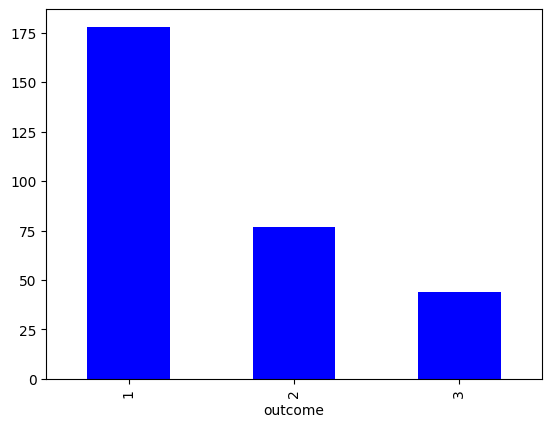

In [20]:
import matplotlib.pyplot as plt
df["outcome"].value_counts().plot(kind="bar",color="blue")
plt.show()

#  Outliers Analysis

/tmp/ipython-input-3420887897.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(cols.values, labels=cols.columns)


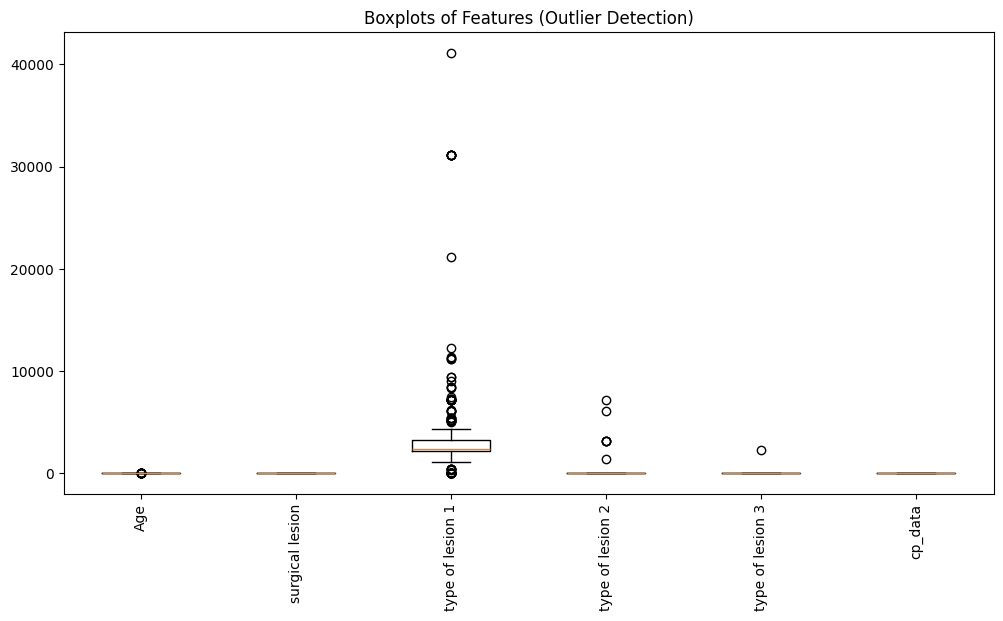

In [21]:
cols = df.drop(columns=["outcome"]).select_dtypes(include=["int64", "float64"])
plt.figure(figsize=(12,6))
plt.boxplot(cols.values, labels=cols.columns)
plt.xticks(rotation=90)
plt.title("Boxplots of Features (Outlier Detection)")
plt.show()


In [22]:
# SKEWNESS CHECK
df["type of lesion 1"].skew()

np.float64(4.337764254457097)

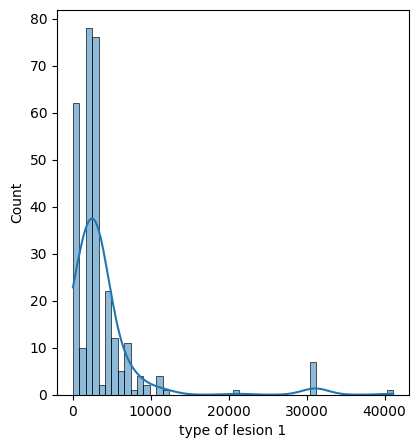

In [23]:
import seaborn as sns
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.histplot(df["type of lesion 1"],kde=True,bins=50)
plt.show()

In [24]:
df["type of lesion 2"].skew()

np.float64(8.29911133982002)

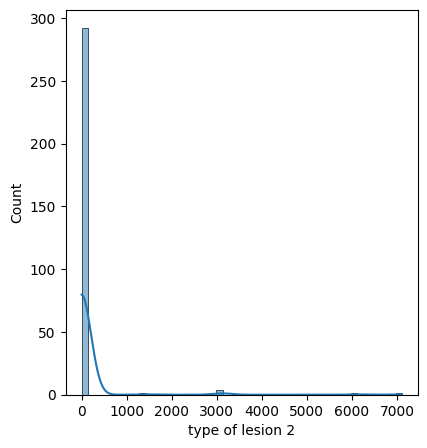

In [25]:
import seaborn as sns
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.histplot(df["type of lesion 2"],kde=True,bins=50)
plt.show()

In [26]:
df.dtypes

,0
surgery,object
Age,int64
rectal temperature,object
pulse,object
respiratory rate,object
temperature of extremities,object
peripheral pulse,object
mucous membranes,object
capillary refill time,object
pain,object


In [27]:
# ALL COLUMNS CONVERTED INTO INT,FLOAT FORMAT BEFORE I FOUND OBJECT IN COLUMNS
for col in df.columns:
  df[col]=pd.to_numeric(df[col],errors="coerce")

In [28]:
df.dtypes

,0
surgery,int64
Age,int64
rectal temperature,float64
pulse,float64
respiratory rate,float64
temperature of extremities,float64
peripheral pulse,float64
mucous membranes,float64
capillary refill time,float64
pain,float64


In [29]:
df.sample(10)

,surgery,Age,rectal temperature,pulse,respiratory rate,temperature of extremities,peripheral pulse,mucous membranes,capillary refill time,pain,...,rectal examination,abdomen,packed cell volume,total protein,outcome,surgical lesion,type of lesion 1,type of lesion 2,type of lesion 3,cp_data
239,1,1,38.1,70.0,22.0,NaN,1.0,NaN,1.0,5.0,...,NaN,5.0,36.0,65.0,3,1,3205,0,0,2
271,1,1,37.7,80.0,NaN,3.0,3.0,6.0,1.0,5.0,...,3.0,1.0,50.0,55.0,1,1,4206,0,0,2
235,1,1,38.1,52.0,24.0,1.0,1.0,5.0,1.0,4.0,...,1.0,NaN,54.0,7.5,2,1,2206,0,0,1
163,1,1,38.0,66.0,20.0,1.0,3.0,3.0,1.0,5.0,...,3.0,NaN,46.0,46.0,3,1,6209,0,0,2
270,1,1,37.5,60.0,50.0,3.0,3.0,1.0,1.0,3.0,...,3.0,4.0,35.0,6.5,2,1,2209,0,0,2
219,1,1,NaN,52.0,28.0,3.0,3.0,4.0,1.0,3.0,...,4.0,4.0,37.0,8.1,1,1,2111,0,0,2
172,1,1,38.5,129.0,48.0,3.0,3.0,3.0,1.0,2.0,...,NaN,NaN,57.0,66.0,1,1,2206,0,0,2
140,1,1,38.1,44.0,9.0,3.0,1.0,1.0,1.0,2.0,...,4.0,5.0,31.0,7.3,1,2,5124,0,0,2
4,2,1,37.3,104.0,35.0,NaN,NaN,6.0,2.0,NaN,...,NaN,NaN,74.0,7.4,2,2,4300,0,0,2
260,2,1,38.0,40.0,25.0,NaN,1.0,1.0,1.0,4.0,...,4.0,NaN,37.0,69.0,1,2,0,0,0,2


In [30]:
X=df.drop(columns="outcome",axis=1)
y=df["outcome"]

# Train test split(80-20)

In [31]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y ,test_size=0.2,stratify=y,random_state=42)


In [32]:
X_train.shape

(239, 23)

Scikit-learn modules were used for preprocessing, imputation, pipeline construction, model training, class balancing, and performance evaluation.


In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils import class_weight

In [45]:
pipeline=Pipeline([("imputer",KNNImputer(n_neighbors=3,weights="distance")),
                  ("scaler",StandardScaler()),
                  ("model",LogisticRegression(class_weight="balanced",max_iter=10))])


In [46]:
pipeline.fit(X_train,y_train)
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.77      0.56      0.65        36
           2       0.50      0.67      0.57        15
           3       0.21      0.33      0.26         9

    accuracy                           0.55        60
   macro avg       0.49      0.52      0.49        60
weighted avg       0.62      0.55      0.57        60

[[20  8  8]
 [ 2 10  3]
 [ 4  2  3]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [47]:
# missing values columns from original dataset
missing_columns=X_train.columns[X_train.isnull().any()]
print(missing_columns)

Index(['rectal temperature', 'pulse', 'respiratory rate',
       'temperature of extremities', 'peripheral pulse', 'mucous membranes',
       'capillary refill time', 'pain', 'peristalsis', 'abdominal distension',
       'nasogastric tube', 'nasogastric reflux', 'rectal examination',
       'abdomen', 'packed cell volume', 'total protein'],
      dtype='object')


In [48]:
# missing values columns after apply knnimputation
imputer=pipeline.named_steps["imputer"]


In [49]:
X_train_imputer=pd.DataFrame(imputer.transform(X_train), columns=X_train.columns)

In [39]:
X_train.isnull().sum()

,0
surgery,0
Age,0
rectal temperature,47
pulse,19
respiratory rate,42
temperature of extremities,45
peripheral pulse,56
mucous membranes,41
capillary refill time,28
pain,46


In [40]:
X_train_imputer.isnull().sum()

,0
surgery,0
Age,0
rectal temperature,0
pulse,0
respiratory rate,0
temperature of extremities,0
peripheral pulse,0
mucous membranes,0
capillary refill time,0
pain,0


# Before(original) and after apply KNNImputation distribution  

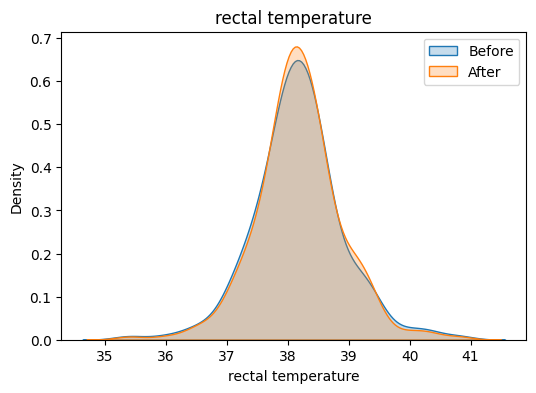

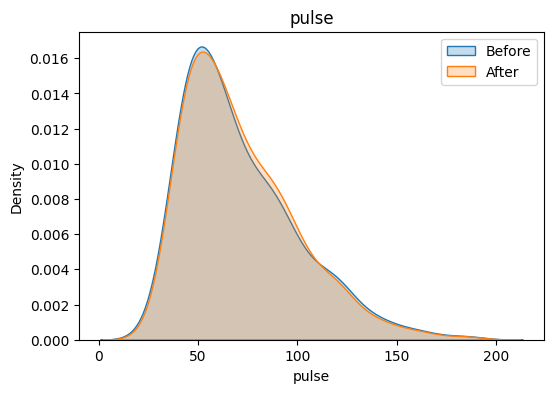

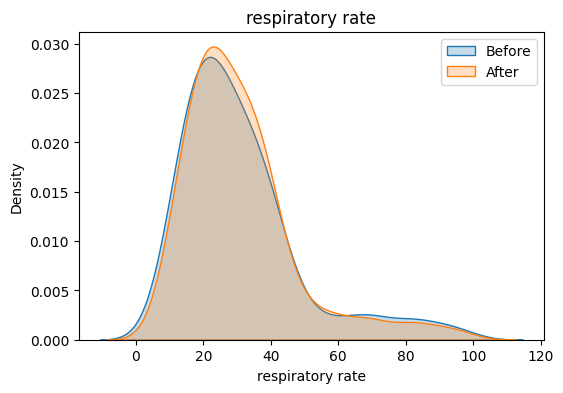

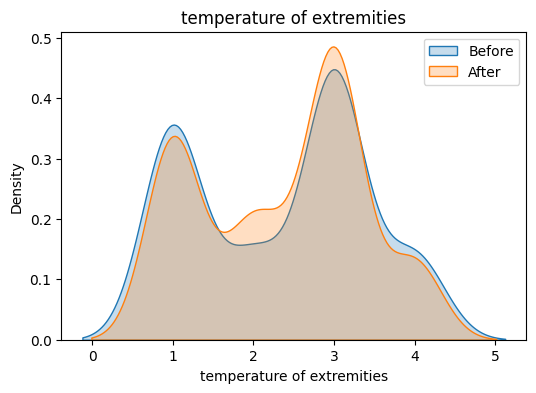

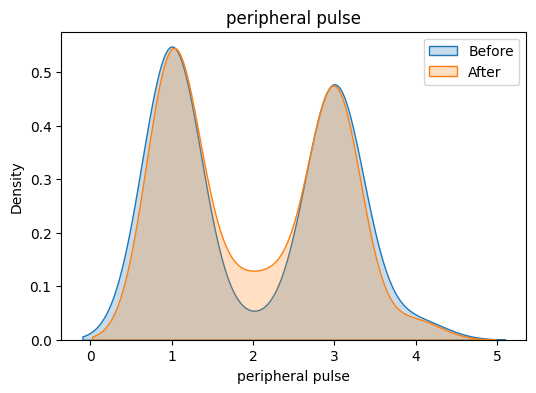

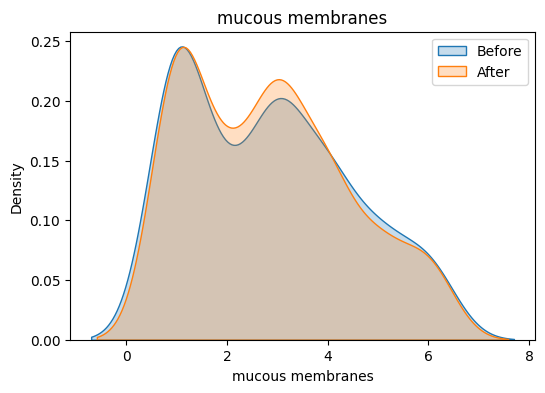

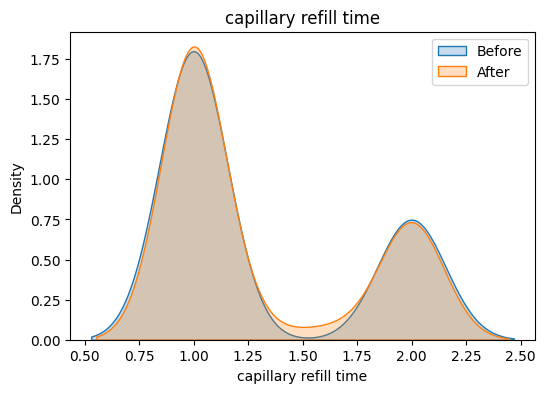

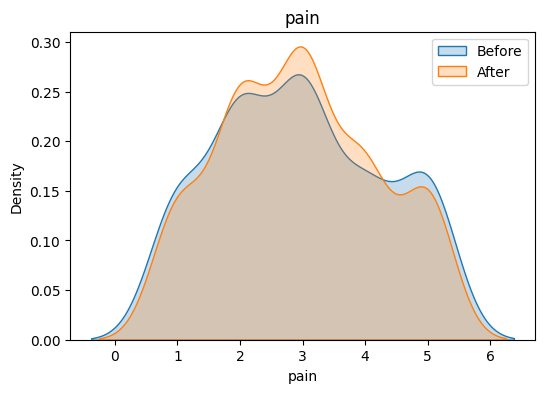

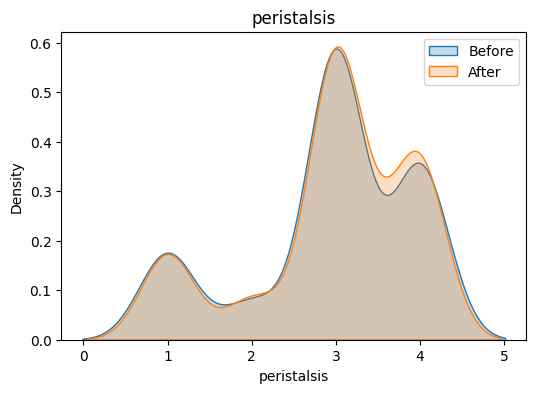

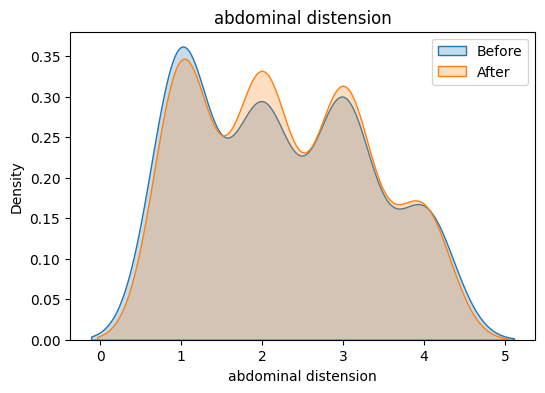

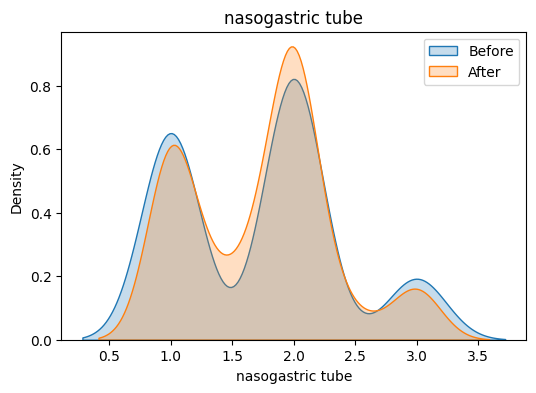

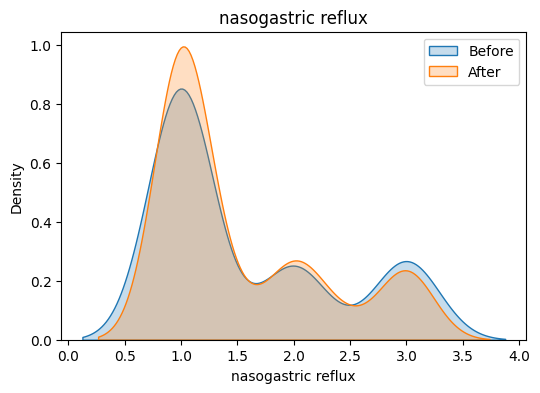

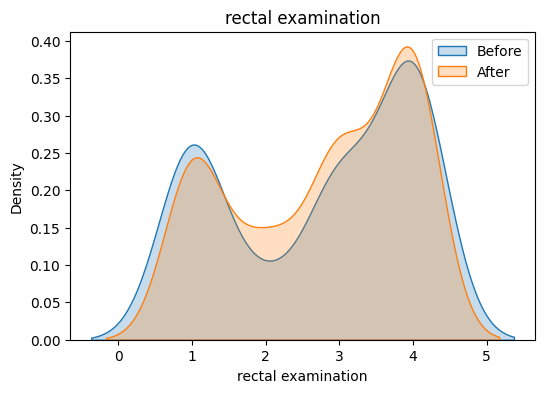

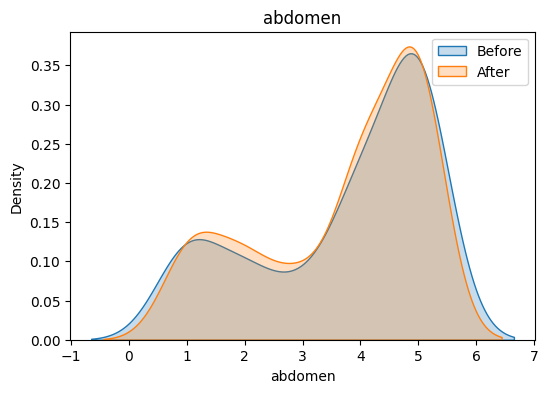

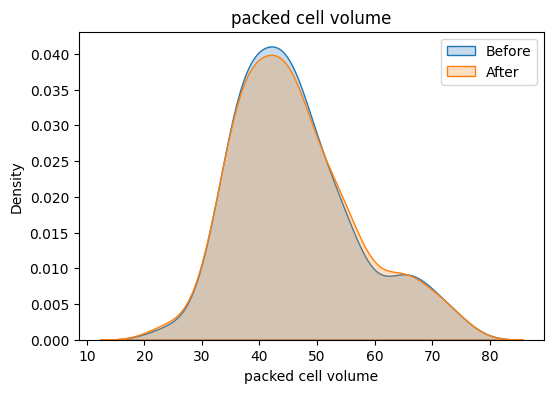

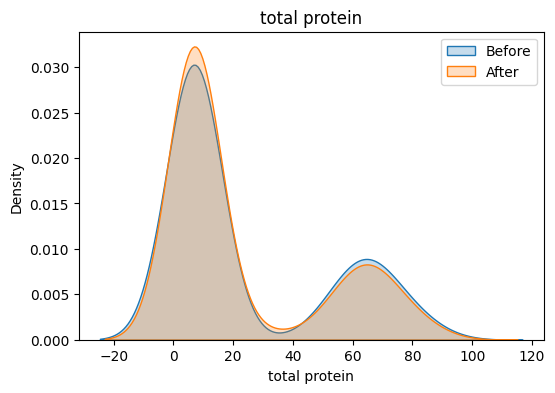

In [41]:
import seaborn as sns
for col in missing_columns:
    plt.figure(figsize=(6,4))
    sns.kdeplot(X_train[col], label="Before", fill=True)
    sns.kdeplot(X_train_imputer[col], label="After", fill=True)
    plt.title(col)
    plt.legend()
    plt.show()

In [42]:
print(X_train.columns.tolist())


['surgery', 'Age', 'rectal temperature', 'pulse', 'respiratory rate', 'temperature of extremities', 'peripheral pulse', 'mucous membranes', 'capillary refill time', 'pain', 'peristalsis', 'abdominal distension', 'nasogastric tube', 'nasogastric reflux', 'rectal examination', 'abdomen', 'packed cell volume', 'total protein', 'surgical lesion', 'type of lesion 1', 'type of lesion 2', 'type of lesion 3', 'cp_data']


In [43]:
col = "surgery"   # example column without NaNs
(X_train[col].values == X_train_imputer[col].values).all()


np.True_